In [1]:
%matplotlib inline
#%matplotlib notebook
#%matplotlib widget

In [2]:
import os
os.chdir('/Users/darapett/Work/Research/TESS/Scattered-Light-Data-Analyses/lightkurve/Projects')
%run main.py

In [3]:
#InSimPy
run = 'community_work_Subjak'
targets = 'targets_{}.csv'.format(run)
#Select model and parameters
# model = 'sinusoidal'
# model_params = {
#     'sinusoidal': {
#         #in e-/s
#         'amplitude': 50,
#         #in 2min cadences 
#         'period' : 5400,
#         #in degrees
#         'phase' : 270
#     }
# }
model = 'double-sinusoidal'
model_params = {
    'double-sinusoidal': {
        #in e-/s
        'amplitude1': 50,
        'amplitude2': 0,
        #in 2min cadences 
        'period1' : 5400,
        'period2' : 1,
        #in degrees
        'phase1' : 45,
        'phase2' : 0
    }
}
#Note that the InSimPy directory names have the suffix '_SV_sims'
mvalstr=str(model_params[model].values())
mval=mvalstr.replace('dict_values([','').replace('])','').replace(', ','-')
save_name_inj = 'saved_{}_SV_sims_sMod-{}_sPar-{}'.format(run,model,mval)
overwrite_ok = True
download = True
plot = False
#Use None to turn off
#null_test = 13077
null_test = None

In [5]:
injector = Simulations_Injector(targets=targets,model=model,model_params=model_params)

In [6]:
injector.inject(save_name=save_name_inj,
                overwrite_ok=overwrite_ok,download=download,plot=plot,null_test=null_test)

In [7]:
cindex=0
tpf = lk.read('{}'.format(cc.tpf_filenames[cindex]),quality_bitmask=quality_bitmask)

In [8]:
tpf_inj = lk.read('{}'.format(injector.tpf_inj_filenames[cindex]),quality_bitmask=quality_bitmask)

In [9]:
lc=tpf.to_lightcurve()
lc_inj=tpf_inj.to_lightcurve()
flux_inj= lc_inj - lc

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

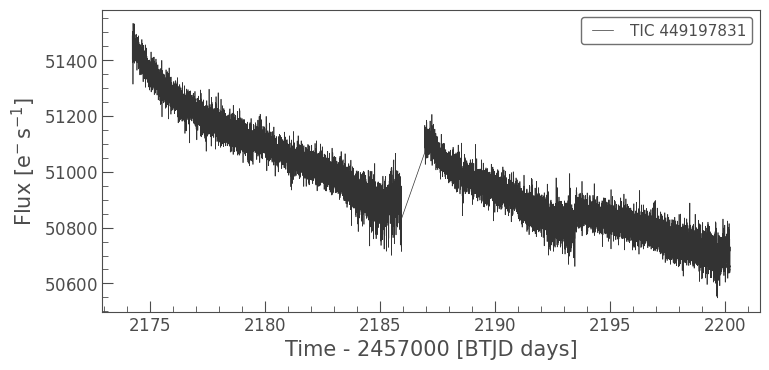

In [10]:
lc.plot()

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

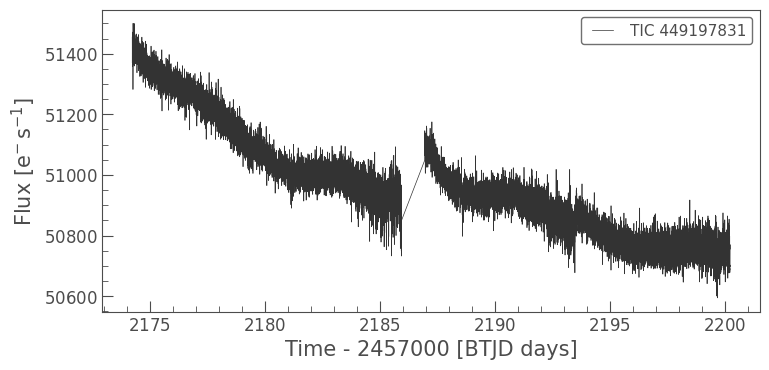

In [11]:
lc_inj.plot()

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

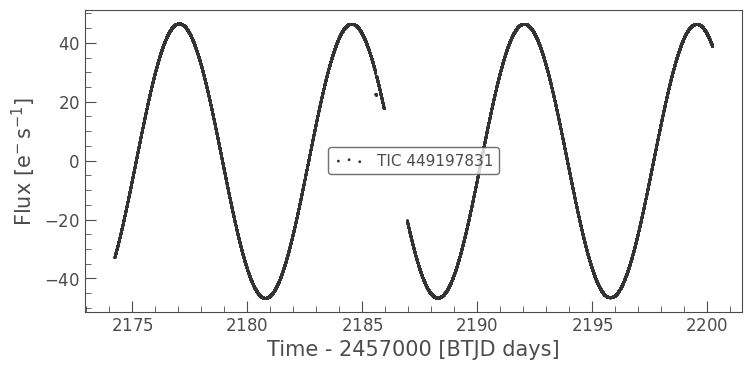

In [12]:
flux_inj.scatter()

In [13]:
#correctors = ['PLD']
#correctors=['PLD','RCQ']
correctors=['PLD','RCQ','CBV']

#select a case or choose None or 'all'
select_case = 'all'
first_cindex = 1
ncases_per_bin = 2
remove_outliers = False
propagate_errors = True

metrics_only = False

plot_type = 'joined_panels'
#plot_type='separate_plots'
binned_lcs = True
bin_size = 0.02
diag_pvar = False
corr_diags = False

#This is deprecated; all variation parameters are plotted at this time
#TODO: Clean up as needed
diag_parName = 'spline_n_knots'

In [14]:
parameters = {
    'RCQ' : {
        'params_to_var'  : {
            'spline_n_knots' : [6,12,24,48],
            'pca_components' : [3,6,9]
        },
        'ntimes_nanstd'  : 10,
        'add_bkg_flag'   : True,
        'bkg_adjust'     : 'median',
        'color'          : 'blue',
        'colormap'       : 'Blues'
    },
    'PLD' : {
        'params_to_var'  : {
            'spline_n_knots'    : [6,12,24,48],
            'pld_aperture_mask' : ['pipeline','threshold'],
            'pca_components'    : [8,16,32]
        },
        'add_bkg_flag'   : True,
        'aperture_mask'  : 'pipeline',
        'bkg_adjust'     : 'median',
        'color'          : 'blueviolet',
        'colormap'       : 'Purples'
    },
    'CBV'  : {
        'params_to_var'  : {
            #'cbv_type'       : [['SingleScale','Spike']],
            #'cbv_indices'    : [[np.arange(1,9), 'ALL']],
            #'cbv_type'       : [['MultiScale.1', 'MultiScale.2', 'MultiScale.3','Spike']],
            #'cbv_indices'    : [[np.arange(1,9), np.arange(1,9), np.arange(1,9), 'ALL']],
            'cbv_type'       : [['MultiScale.1', 'MultiScale.2', 'MultiScale.3','Spike'],['SingleScale','Spike']],
            'cbv_indices'    : [[np.arange(1,9), np.arange(1,9), np.arange(1,9), 'ALL'],[np.arange(1,9), 'ALL']],
            #'cbv_type'       : [['MultiScale.3','Spike'],['SingleScale','Spike']],
            #'cbv_indices'    : [[np.arange(1,9), 'ALL'],[np.arange(1,9), 'ALL']],
            #'alpha_reg'      : [1e-4,1e-3,1e-2,1e-1,1,1e+1,1e+2],
            'alpha_reg'      : [1e-4,1e-2,1],
            #'alpha_reg'      : [1e-4],
            #'spline_flag'    : [False,True,True,True],
            'spline_flag'    : [False],
            #'spline_n_knots' : [0,4,6,8]
            'spline_n_knots' : [0]
            #'spline_n_knots' : [0,6,12,24,48,96]
        },
        'add_bkg_flag'   : False,
        'auto_reg'       : False,
        'color'          : 'green',
        'colormap'       : 'Greens'
    },
    'PDC'  : {
        'color'          : 'red',
        'colormap'       : 'Reds'
    }
}

In [15]:
comparer_inj = Correctors_Comparer(targets=targets,input_filenames=injector.tpf_inj_filenames,
                                   select_case=select_case,
                                   first_cindex=first_cindex,
                                   ncases_per_bin=ncases_per_bin,
                                   remove_outliers=remove_outliers,
                                   propagate_errors=propagate_errors,
                                   diag_pvar=diag_pvar,diag_parName=diag_parName,
                                   correctors=correctors,save_name=save_name_inj,
                                   overwrite_ok=overwrite_ok,parameters=parameters)

In [18]:
#%%time
#comparer_inj.compare(save_name=save_name_inj,overwrite_ok=overwrite_ok,download=download,
#                 metrics_only=metrics_only,corr_diags=corr_diags)

In [19]:
#%%time
#comparer_inj.comparison_plots(cindex=select_case,plot_type=plot_type,binned_lcs=binned_lcs,bin_size=bin_size,
#                          correctors=correctors,save_name=save_name_inj,
#                          overwrite_ok=overwrite_ok,SAP_flag=False)

In [20]:
save_name = 'saved_{}'.format(run)

In [21]:
comparer = Correctors_Comparer(targets=targets,input_filenames=None,
                               select_case=select_case,
                               first_cindex=first_cindex,
                               ncases_per_bin=ncases_per_bin,
                               remove_outliers=remove_outliers,
                               propagate_errors=propagate_errors,
                               diag_pvar=diag_pvar,diag_parName=diag_parName,
                               correctors=correctors,save_name=save_name,
                               overwrite_ok=overwrite_ok,parameters=parameters)

In [22]:
#%%time
#comparer.compare(save_name=save_name,overwrite_ok=overwrite_ok,download=download,
#                 metrics_only=metrics_only,corr_diags=corr_diags)

In [23]:
#%%time
#comparer.comparison_plots(cindex=select_case,plot_type=plot_type,binned_lcs=binned_lcs,bin_size=bin_size,
#                          correctors=correctors,save_name=save_name,
#                          overwrite_ok=overwrite_ok,SAP_flag=False)

In [589]:
lc_pdc=lk.read('{}'.format(comparer.spoc_lc_filenames[0]),quality_bitmask=quality_bitmask)

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

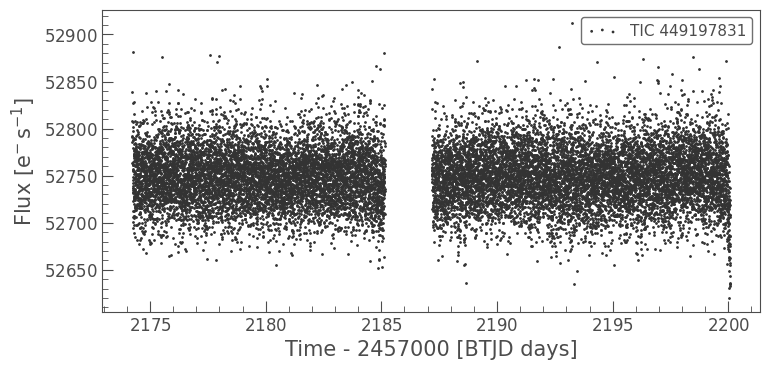

In [602]:
lc_pdc.scatter()

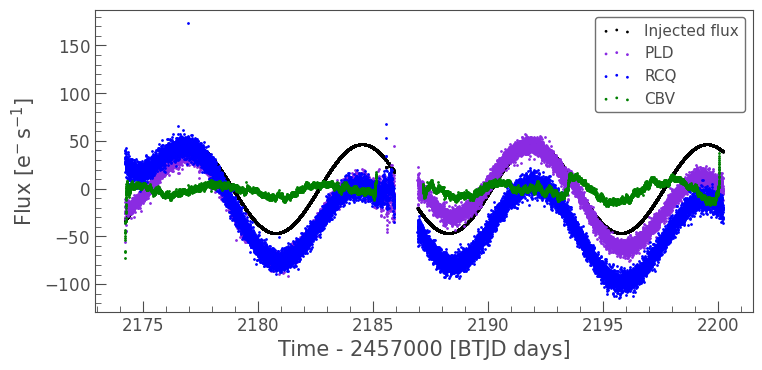

In [27]:
ax=flux_inj.scatter(c='black',label='Injected flux')
corr_index=0
for corrector in correctors:
    corr_inj = lk.read('{}'.format(comparer_inj.corr_lc_filenames[corr_index]),
                       quality_bitmask=quality_bitmask)
    corr = lk.read('{}'.format(comparer.corr_lc_filenames[corr_index]),quality_bitmask=quality_bitmask)
    corr_inj_var = corr_inj - corr
    ax = corr_inj_var.scatter(ax=ax,c=comparer_inj.parameters[corrector]['color'],label=corrector)
    corr_index=corr_index+1

fig_format='pdf'
combined_correctors=''
for corrector in correctors:
    combined_correctors+=corrector+'_'
fig_filename = '{}SV_sims_sMod-{}_sPar-{}_injection_comparison_residuals.{}'.format(
    combined_correctors,model,mval,fig_format)
ax.figure.savefig(comparer_inj.path_to_png+fig_filename,format=fig_format)

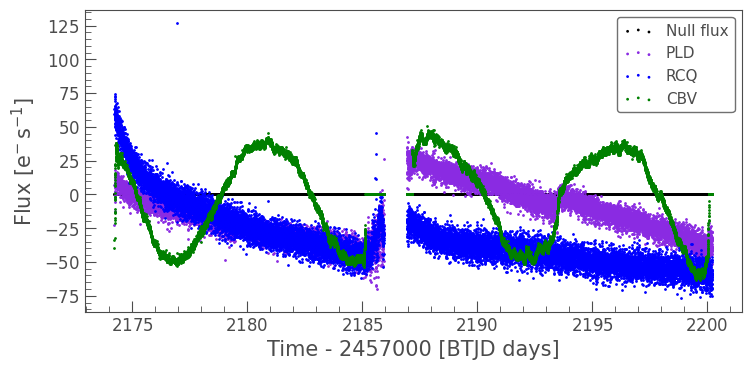

In [30]:
null_inj = flux_inj - flux_inj
ax=null_inj.scatter(c='black',label='Null flux')
corr_index=0
for corrector in correctors:
    corr_inj = lk.read('{}'.format(comparer_inj.corr_lc_filenames[corr_index]),
                       quality_bitmask=quality_bitmask)
    corr = lk.read('{}'.format(comparer.corr_lc_filenames[corr_index]),
                   quality_bitmask=quality_bitmask)
    corr_inj_var = corr_inj - corr
    corr_res = copy.deepcopy(null_inj)
    i=0
    for count in np.arange(len(null_inj)):
        try:
            if corr_inj_var.cadenceno[i] == null_inj.cadenceno[count]:
                corr_res.flux[count] = corr_inj_var.flux[i] - flux_inj.flux[count]
                i=i+1
        except:
            pass
    corr_res.scatter(ax=ax,c=comparer_inj.parameters[corrector]['color'],label=corrector)
    corr_index=corr_index+1
    
fig_format='pdf'
combined_correctors=''
for corrector in correctors:
    combined_correctors+=corrector+'_'
fig_filename = '{}SV_sims_sMod-{}_sPar-{}_injection_comparison_residuals_flattened.{}'.format(
    combined_correctors,model,mval,fig_format)
ax.figure.savefig(comparer_inj.path_to_png+fig_filename,format=fig_format)

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

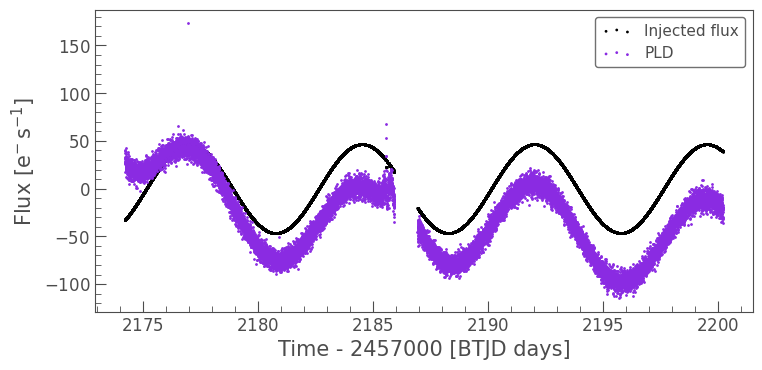

In [72]:
ax=flux_inj.scatter(c='black',label='Injected flux')
corr_index=1
corrector='PLD'
corr_inj = lk.read('{}'.format(comparer_inj.corr_lc_filenames[corr_index]),
                    quality_bitmask=quality_bitmask)
corr = lk.read('{}'.format(comparer.corr_lc_filenames[corr_index]),quality_bitmask=quality_bitmask)
corr_inj_var = corr_inj - corr
corr_inj_var.scatter(ax=ax,c=comparer_inj.parameters[corrector]['color'],label=corrector)

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

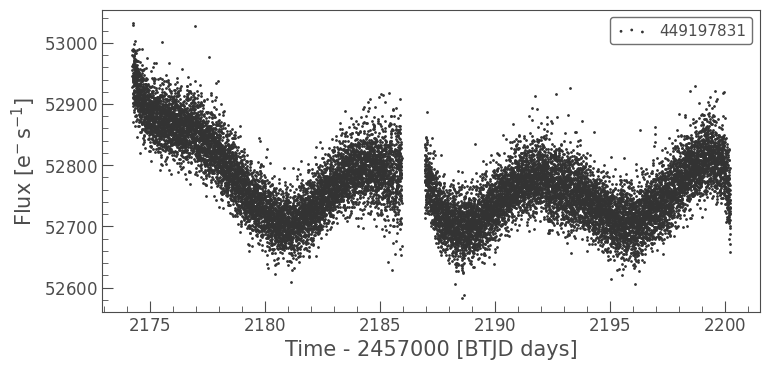

In [73]:
corr_inj.scatter()

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

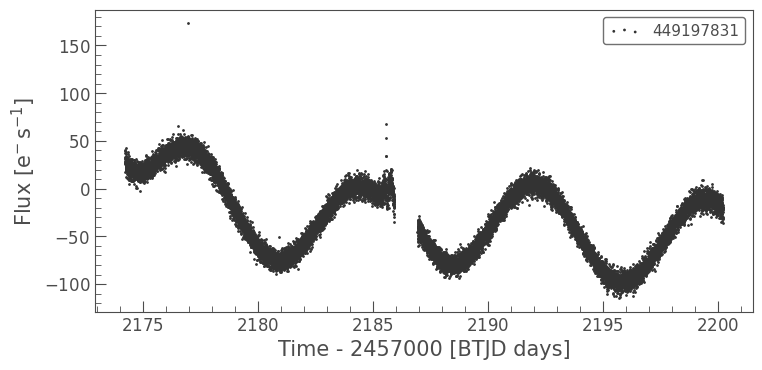

In [74]:
corr_inj_var.scatter()

In [75]:
# Find cadences present in both light curves
common_cadences = np.intersect1d(corr_inj_var.cadenceno, flux_inj.cadenceno)

# Mask lc2 to only those common cadences
flux_inj_masked = flux_inj[np.in1d(flux_inj.cadenceno, common_cadences)]
# You must also mask lc1 to be consistent
corr_inj_var_masked = corr_inj_var[np.in1d(corr_inj_var.cadenceno, common_cadences)]

In [425]:
slope=corr.time.value-np.median(corr.time.value)
dm1 = lk.DesignMatrix(slope, name='slope')
#dm = lk.DesignMatrix(corr_inj_var_masked.flux.value, name='data')
dm2 = lk.DesignMatrix(flux_inj_masked.flux.value, name='injection')
dmc = dm1.collect(dm2)
dm = dmc.to_designmatrix(name="Combined Design Matrix")
dm = dm.append_constant()
condition_number_before_cond=np.linalg.cond(dm.X)

In [430]:
dm = dm.standardize()
condition_number_after_cond=np.linalg.cond(dm.X)
print('Condition Number Before Conditioning',condition_number_before_cond)
print('Condition Number After Conditioning',condition_number_after_cond)
dm.validate()

Condition Number Before Conditioning 33.64950172065975
Condition Number After Conditioning 1.1066016521930284


<AxesSubplot:title={'center':'Combined Design Matrix'}, xlabel='Component', ylabel='X'>

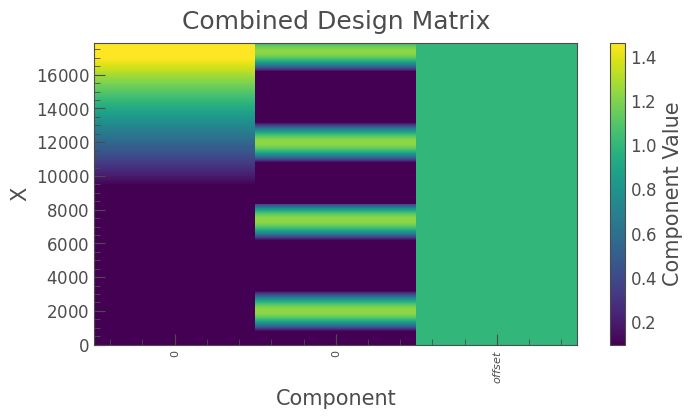

In [345]:
dm.plot()

In [346]:
rc=lk.RegressionCorrector(corr_inj_var_masked)
#rc=lk.RegressionCorrector(flux_inj_masked)
corr_rc_lc=rc.correct(dm)

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

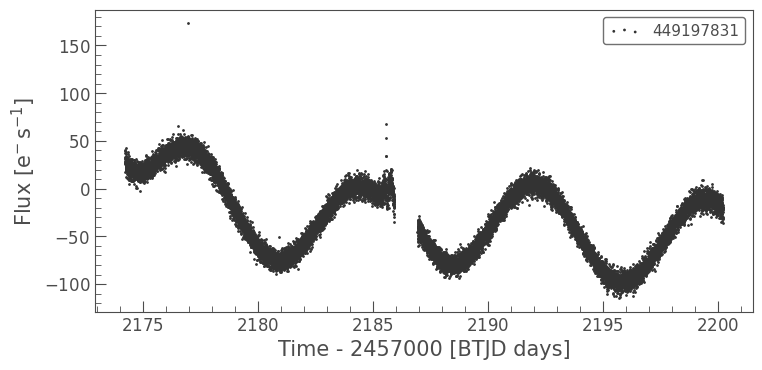

In [347]:
rc.lc.scatter()

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

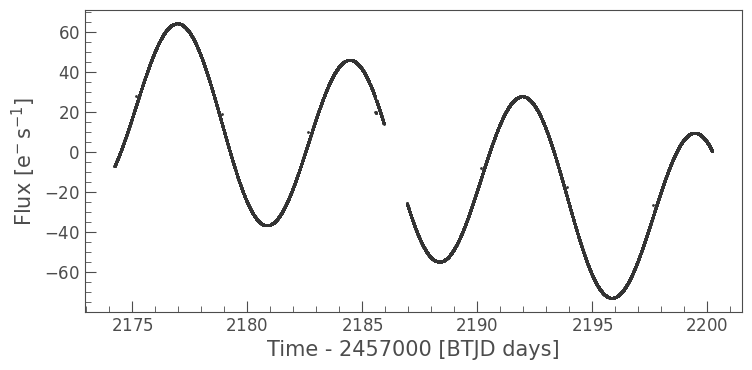

In [348]:
rc.model_lc.scatter()

In [349]:
#corr_inj_var_masked.flux = corr_inj_var_masked.flux * rc.coefficients[1] #+ rc.coefficients[1]
#fitted_rc.scatter(ax=ax, label='Fit')

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

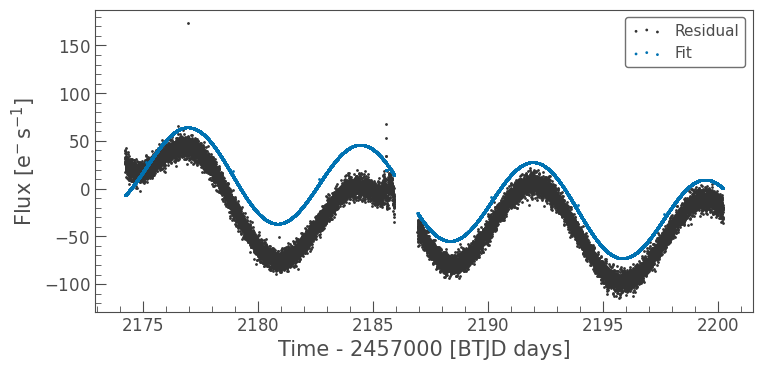

In [350]:
ax=corr_inj_var_masked.scatter(label='Residual')
rc.model_lc.scatter(ax=ax, label='Fit')

In [351]:
#median-shift align as in the diagnostic plot
model_lc=rc.model_lc
aligned_model_lc=model_lc.copy()
median_alignment=-np.median(model_lc.flux)+np.median(corr_inj_var_masked.flux)
aligned_model_lc.flux=model_lc.flux+median_alignment

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

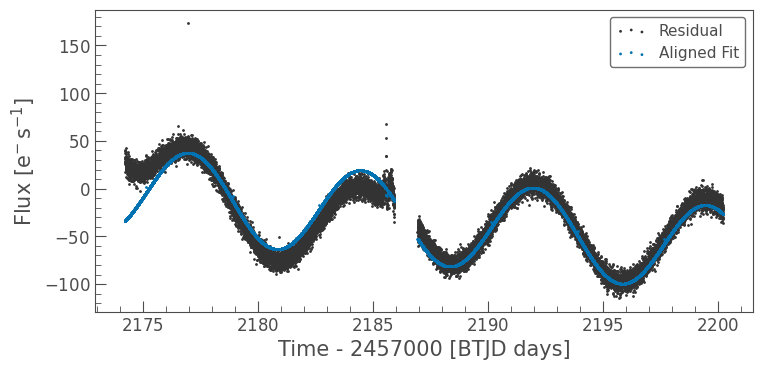

In [353]:
ax=corr_inj_var_masked.scatter(label='Residual')
aligned_model_lc.scatter(ax=ax, label='Aligned Fit')

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

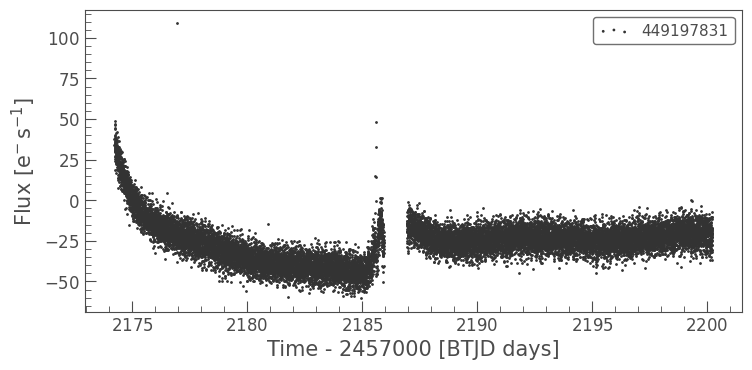

In [354]:
corr_rc_lc.scatter()

array([<AxesSubplot:ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>,
       <AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>],
      dtype=object)

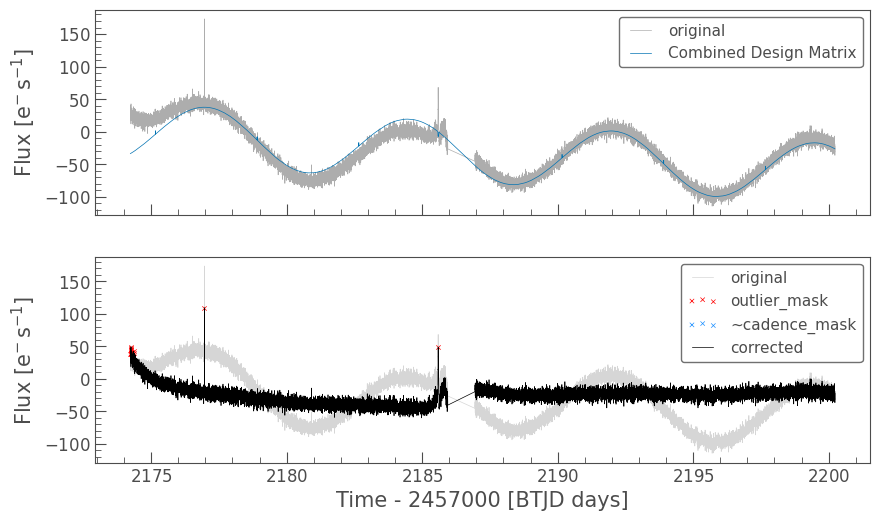

In [355]:
rc.diagnose()

In [356]:
rc.coefficients

array([-18.56898634,  32.78106908, -28.17183711])

<AxesSubplot:xlabel='Time [JD]', ylabel='Flux'>

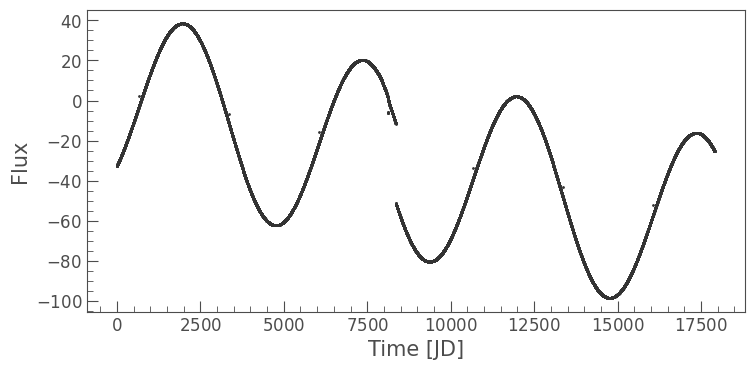

In [357]:
test_model=np.inner(rc.coefficients,dm.X)
time=np.arange(1,17907)
test_model_lc = lk.LightCurve(time=time, flux=test_model)
test_model_lc.scatter()

<AxesSubplot:xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

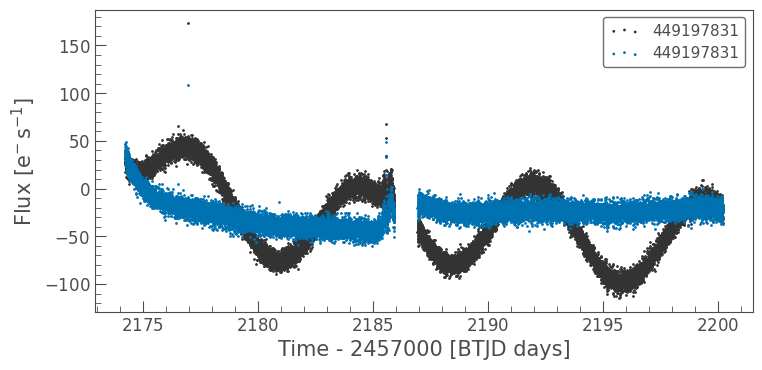

In [358]:
ax=rc.lc.scatter()
rc.corrected_lc.scatter(ax=ax)

In [359]:
#Testing RMS before and after the fit
RMS_before = np.std(rc.lc.flux)
RMS_after = np.std(rc.corrected_lc.flux)
RMS_improvement = RMS_before / RMS_after
RMS_improvement

<Quantity 3.12164719>

In [360]:
#Checks that residuals corresponds to the corrected model
#residuals = rc.lc - rc.model_lc
#ax=rc.corrected_lc.scatter()
#residuals.scatter(ax=ax)
#(rc.corrected_lc-residuals).scatter()

In [361]:
median = np.median(rc.lc.flux)
MAD_before = np.median(np.abs(rc.lc.flux - median))
median = np.median(rc.corrected_lc.flux)
MAD_after = np.median(np.abs(rc.corrected_lc.flux - median))
MAD_improvement = MAD_before / MAD_after
MAD_improvement

<Quantity 4.73083344>

<AxesSubplot:xlabel='Period [$\\mathrm{d}$]', ylabel='Power [$\\mathrm{\\frac{e^{-}}{s}}$]'>

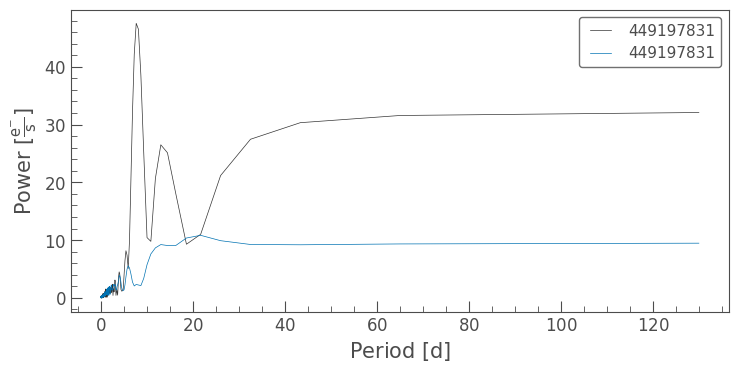

In [378]:
periodogram_before=rc.lc.to_periodogram()
ax=periodogram_before.plot(view='period')
periodogram_after=rc.corrected_lc.to_periodogram()
periodogram_after.plot(ax=ax,view='period')

In [432]:
periodogram_before.period_at_max_power

<Quantity 7.64590882 d>

In [512]:
def band_power_ratio(
    lc_before, lc_after, target_period,
    normalization="amplitude",         # "amplitude" or "psd"
    oversample_factor=10,               # 5–10 recommended
    bandwidth="rayleigh",               # "rayleigh" or a Quantity like 0.05/u.day
    method="integrated",                # "integrated" or "max"
    nterms=1,                           # LS harmonics; keep 1 for a simple sinusoid
    freq_unit=1/u.day,                  # or 1/u.hour, 1/u.s, etc.
):
    """
    Compare periodogram power around `target_period` before vs after the fit.
    Returns a dict with the ratio and some context.
    """
    
    from lightkurve.periodogram import LombScarglePeriodogram
    
    # --- Build periodograms using Lightkurve ---
    p_before = LombScarglePeriodogram.from_lightcurve(
        lc_before, normalization=normalization,
        oversample_factor=oversample_factor, nterms=nterms, freq_unit=freq_unit
    )
    p_after = LombScarglePeriodogram.from_lightcurve(
        lc_after, normalization=normalization,
        oversample_factor=oversample_factor, nterms=nterms, freq_unit=freq_unit
    )

    # Convert target period to frequency
    target_period = u.Quantity(target_period)  # ensure Quantity
    f0 = (1 / target_period).to(freq_unit)     # target frequency

    # Determine a frequency bandwidth
    if bandwidth == "rayleigh":
        # Rayleigh resolution ~ 1 / time baseline
        T = (lc_before.time.max() - lc_before.time.min()).to(u.day)
        df = (1 / T).to(freq_unit)
    else:
        df = u.Quantity(bandwidth).to(freq_unit)

    fmin = np.maximum((f0 - df).value, p_before.frequency.min().value) * freq_unit
    fmax = np.minimum((f0 + df).value, p_before.frequency.max().value) * freq_unit

    # Build masks selecting the band in frequency space
    mask_before = (p_before.frequency >= fmin) & (p_before.frequency <= fmax)
    mask_after  = (p_after.frequency  >= fmin) & (p_after.frequency  <= fmax)

    # Metric: either integrate power in the band or take the max
    if method == "integrated":
        # Trapezoidal integration of power over frequency
        # (Units are consistent with Lightkurve’s periodogram; see docs.)
        band_power_before = np.trapz(
            p_before.power[mask_before].value,
            p_before.frequency[mask_before].to_value(freq_unit)
        )
        band_power_after = np.trapz(
            p_after.power[mask_after].value,
            p_after.frequency[mask_after].to_value(freq_unit)
        )
    elif method == "max":
        band_power_before = np.max(p_before.power[mask_before].value) if np.any(mask_before) else 0.0
        band_power_after  = np.max(p_after.power[mask_after].value) if np.any(mask_after) else 0.0
    else:
        raise ValueError("method must be 'integrated' or 'max'")

    # Avoid division by zero
    ratio = (band_power_after / band_power_before) if band_power_before > 0 else np.nan

    return {
        "ratio_after_over_before": ratio,
        "band_power_before": band_power_before,
        "band_power_after": band_power_after,
        "band_freq_min": fmin,
        "band_freq_max": fmax,
        "target_frequency": f0,
        "periodogram_before": p_before,
        "periodogram_after": p_after,
    }, p_before, p_after

In [568]:
# rc.lc: original
# corrected_lc: output from rc.correct(dmc)
# target sinusoid period:
period_min = model_params.get('double-sinusoidal').get('period1') * 2 * u.minute
period_day = period_min.to(u.day)
#period_day=periodogram_before.period_at_max_power

metric = band_power_ratio(
    rc.lc,
    rc.corrected_lc,
    target_period=period_day,
    normalization="amplitude",         # or "psd"
    #normalization="psd",
    oversample_factor=5,
    #bandwidth="rayleigh",              # or 0.02/u.day
    bandwidth=0.01/u.day,
    #method="integrated",
    method='max',
    freq_unit=1/u.day,
)

#print(f"Power ratio (after/before) near {period_day:.2f}: {metric['ratio_after_over_before']:.2f}")

In [569]:
metric[0]

{'ratio_after_over_before': 0.04882017241534698,
 'band_power_before': 47.53833574935681,
 'band_power_after': 2.320829747622253,
 'band_freq_min': <Quantity 0.12333333 1 / d>,
 'band_freq_max': <Quantity 0.14333333 1 / d>,
 'target_frequency': <Quantity 0.13333333 1 / d>,
 'periodogram_before': LombScarglePeriodogram(ID: 449197831),
 'periodogram_after': LombScarglePeriodogram(ID: 449197831)}

<AxesSubplot:xlabel='Period [$\\mathrm{d}$]', ylabel='Power [$\\mathrm{\\frac{e^{-}}{s}}$]'>

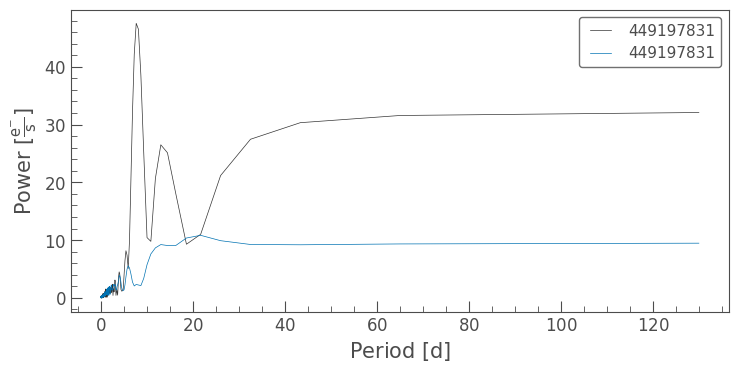

In [519]:
ax=metric[1].plot(view='period')
metric[2].plot(ax=ax,view='period')